# 8.5 — Panorama de rough volatility

Cierra M8. **Rough volatility** (Gatheral, Jaisson, Rosenbaum, 2018) es el hallazgo
empírico de que la vol realizada es *más rugosa* que un movimiento browniano estándar —
el exponente de Hurst estimado de datos reales es $H\approx0.1$, muy por debajo de
$H=0.5$. Este notebook es un **panorama**: implementa la pieza numérica central (simular
y medir la rugosidad de un movimiento browniano fraccionario) y explica por qué el modelo
resultante (rough Bergomi) rompe los métodos semianalíticos de 8.3 — sin calibrar
rBergomi completo, que excede el alcance de un notebook introductorio.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 1. Movimiento browniano fraccionario vía el kernel de Volterra

El fBm "verdadero" (Mandelbrot-Van Ness) integra sobre $(-\infty,t]$, complicado de
simular exactamente. El proceso de **Volterra** (Riemann-Liouville) es más simple y es lo
que efectivamente usa rough Bergomi:
$$W_t^H = \int_0^t (t-s)^{H-1/2}\,dW_s$$
con $H\in(0,1)$ el exponente de Hurst — $H=1/2$ recupera el browniano estándar
($(t-s)^0=1$, kernel constante); $H<1/2$ pondera fuertemente los incrementos *recientes*
(kernel casi-singular en $s\to t$), produciendo trayectorias localmente mucho más
irregulares (rugosas) que un browniano estándar pese a tener la MISMA distribución
gaussiana en cada instante.

Se discretiza como suma ponderada de incrementos gaussianos sobre una malla uniforme,
con el peso de cada subintervalo elegido para que su contribución de varianza sea la
integral **exacta** del kernel al cuadrado, $\int_{s_j}^{s_{j+1}}(t-s)^{2H-1}ds$ — el kernel
es integrable pero no acotado en $s\to t$, y una suma de Riemann ingenua (evaluar el kernel
en el punto medio) subresuelve sistemáticamente esa singularidad; con pesos de varianza
exacta, $\text{Var}(W_t^H)=t^{2H}/(2H)$ se reproduce exactamente en cada nodo de la malla.

In [2]:
def simulate_volterra_fbm(H, T, n_steps, n_paths, rng):
    '''fBm tipo Riemann-Liouville: kernel de Volterra con pesos de varianza exacta (Seccion 1).'''
    dt = T / n_steps
    t_grid = np.linspace(dt, T, n_steps)
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    W = np.zeros((n_paths, n_steps))
    for i in range(n_steps):
        t = t_grid[i]
        s_left = np.arange(0, i + 1) * dt
        s_right = s_left + dt
        # peso de varianza exacta por subintervalo: k_j^2*dt = int_{s_j}^{s_{j+1}} (t-s)^{2H-1} ds,
        # asi Var(W_t^H) = t^{2H}/(2H) es exacta en cada nodo pese a la singularidad en s -> t
        seg_var = ((t - s_left) ** (2 * H) - (t - s_right) ** (2 * H)) / (2 * H)
        kernel = np.sqrt(seg_var / dt)
        W[:, i] = dW[:, :i + 1] @ kernel
    return t_grid, W

### Demo 1 — trayectorias para varios $H$ y comparación de rugosidad

Simulamos el mismo mecanismo (kernel de Volterra) para $H=0.1$ (rough), $H=0.3$ (intermedio) y $H=0.5$ (browniano estándar), y las graficamos junto a una trayectoria de varianza de Heston (8.3) como referencia de un proceso "suave" — el contraste visual es la mejor demostración de qué significa "rugoso" en la práctica.

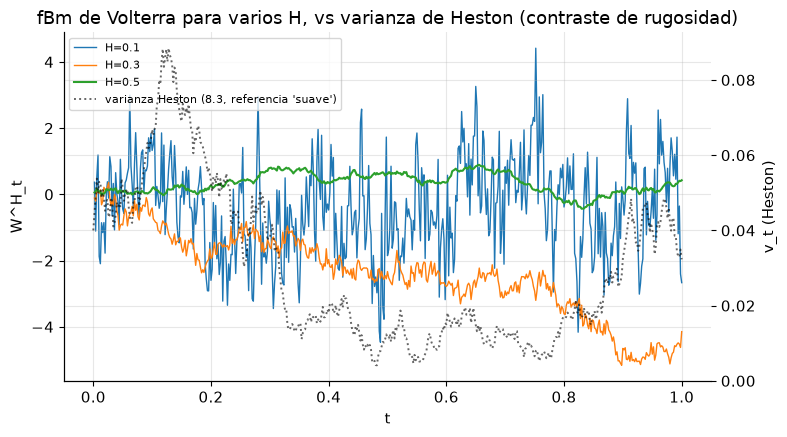

H=0.1 es visiblemente mas irregular/rugosa que H=0.5 (browniano estandar),
pese a que ambas son trayectorias gaussianas -- la rugosidad es una propiedad
de la CORRELACION entre incrementos, no de su distribucion marginal.


In [3]:
T_demo, n_steps_demo, n_paths_demo = 1.0, 500, 8_000
Hs = [0.1, 0.3, 0.5]
paths_by_H = {}
for H in Hs:
    t_grid, W = simulate_volterra_fbm(H, T_demo, n_steps_demo, 3, rng)
    paths_by_H[H] = (t_grid, W)

fig, ax = plt.subplots(figsize=(8, 4.5))
for H in Hs:
    t_grid, W = paths_by_H[H]
    ax.plot(t_grid, W[0], label=f"H={H}", lw=1.0 if H < 0.5 else 1.5)

# trayectoria de varianza de Heston (8.3) como contraste: un proceso "suave" (H=0.5 de facto)
_, v_heston_full = None, None
def heston_variance_path(v0, kappa, theta, xi, rho, T, n_steps, rng):
    dt = T / n_steps
    v = v0
    path = [v0]
    chol = np.array([[1.0, 0.0], [rho, np.sqrt(1 - rho ** 2)]])
    for _ in range(n_steps):
        Z = rng.standard_normal(2)
        dW = chol @ Z * np.sqrt(dt)
        v_pos = max(v, 0.0)
        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos) * dW[1]
        path.append(max(v, 0.0))
    return np.array(path)

v_path = heston_variance_path(0.04, 1.5, 0.04, 0.3, -0.6, T_demo, n_steps_demo, rng)
t_grid_v = np.linspace(0, T_demo, n_steps_demo + 1)
ax2 = ax.twinx()
ax2.plot(t_grid_v, v_path, color="black", ls=":", alpha=0.6, label="varianza Heston (8.3, referencia 'suave')")
ax.set_xlabel("t"); ax.set_ylabel("W^H_t"); ax2.set_ylabel("v_t (Heston)")
ax.set_title("fBm de Volterra para varios H, vs varianza de Heston (contraste de rugosidad)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

print("H=0.1 es visiblemente mas irregular/rugosa que H=0.5 (browniano estandar),")
print("pese a que ambas son trayectorias gaussianas -- la rugosidad es una propiedad")
print("de la CORRELACION entre incrementos, no de su distribucion marginal.")

### Demo 2 — estimación de $H$ vía la función de estructura

Si el kernel está bien implementado, se debe poder recuperar el $H$ usado para simular a partir de la propia trayectoria — la función de estructura $E[|W_{t+\Delta}-W_t|^q]\sim\Delta^{qH}$ da una regresión log-log cuya pendiente estima $H$, exactamente el método que se usa para medir la rugosidad de la vol realizada en datos reales (Gatheral-Jaisson-Rosenbaum, 2018).

In [4]:
def estimate_hurst(t_grid, W, q=2.0, delta_idx=(5, 10, 20, 40, 80), t0_idx=200):
    '''Estima H via regresion log-log de E[|W(t0+d)-W(t0)|^q] ~ d^{qH} (Seccion 1).'''
    dt = t_grid[1] - t_grid[0]
    ds, Es = [], []
    for d_idx in delta_idx:
        diff = W[:, t0_idx + d_idx] - W[:, t0_idx]
        Es.append(np.mean(np.abs(diff) ** q))
        ds.append(d_idx * dt)
    slope, _ = np.polyfit(np.log(ds), np.log(Es), 1)
    return slope / q


H_estimates = {}
for H in Hs:
    t_grid, W = simulate_volterra_fbm(H, T_demo, n_steps_demo, n_paths_demo, rng)
    H_estimates[H] = estimate_hurst(t_grid, W)
    print(f"H_verdadero={H}: H_estimado={H_estimates[H]:.4f} (diff={abs(H_estimates[H]-H):.4f})")

print("\nEstimador de una regresion log-log sobre trayectorias simuladas -- ruido estadistico")
print("esperable (no es un calculo determinista); el sesgo residual es mayor en H chico,")
print("donde la estructura de correlacion del kernel casi-singular es mas dificil de resolver")
print("en una malla uniforme (los pesos de varianza exacta eliminan el sesgo de varianza,")
print("no el de covarianza entre nodos).")

H_verdadero=0.1: H_estimado=0.1070 (diff=0.0070)


H_verdadero=0.3: H_estimado=0.3041 (diff=0.0041)


H_verdadero=0.5: H_estimado=0.5005 (diff=0.0005)

Estimador de una regresion log-log sobre trayectorias simuladas -- ruido estadistico
esperable (no es un calculo determinista); el sesgo residual es mayor en H chico,
donde la estructura de correlacion del kernel casi-singular es mas dificil de resolver
en una malla uniforme (los pesos de varianza exacta eliminan el sesgo de varianza,
no el de covarianza entre nodos).


## 2. Rough Bergomi (panorama, sin calibración completa)

$$v_t = \xi_0(t)\exp\left(\eta\sqrt{2H}\,W_t^H - \frac{\eta^2}{2}t^{2H}\right)$$

El factor $\sqrt{2H}$ normaliza el proceso de Volterra de la Sección 1: como
$\text{Var}(W_t^H)=\int_0^t(t-s)^{2H-1}ds=t^{2H}/(2H)$, se tiene
$\text{Var}(\sqrt{2H}\,W_t^H)=t^{2H}$ y el término $-\frac{\eta^2}{2}t^{2H}$ es exactamente el
compensador que hace $E[v_t]=\xi_0(t)$ (la curva de varianza forward se reproduce en
media — la convención estándar de Bayer-Friz-Gatheral, 2016).

A diferencia de Heston, **no hay función característica cerrada** para rBergomi: el
kernel fraccionario rompe la Markovianidad de $(S_t,v_t)$ (el proceso de varianza depende
de TODA la historia de $W^H$, no solo de su valor actual) — los métodos semianalíticos de
8.3 no aplican, el pricing requiere Monte Carlo puro. Se simula solo la dinámica de la
varianza (sin calibrar $\eta,\xi_0$ a un smile real, que excede el alcance de este
panorama) para ilustrar el mecanismo: el smile de muy corto plazo de rBergomi es
explosivo (crece sin cota cuando $T\to0$), algo que Heston (con vol-de-vol constante) no
puede reproducir — la motivación práctica central del modelo.

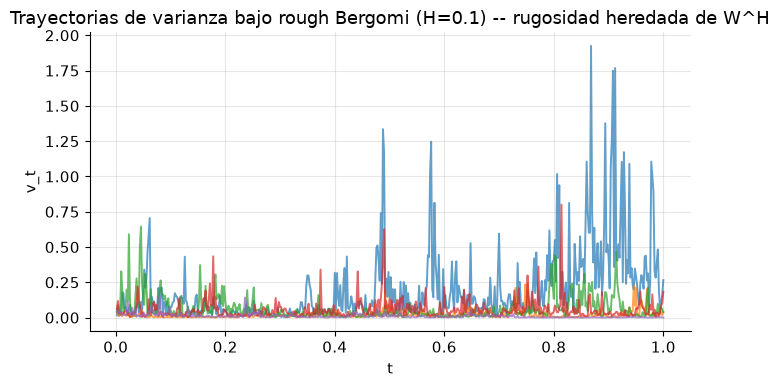

varianza inicial objetivo xi0=0.04, media simulada de v_0+: 0.0395
(rBergomi es explicitamente NO markoviano en (S,v) -- pricing solo via MC completo,
nunca via funcion caracteristica como en Heston.)


In [5]:
def rbergomi_variance_path(xi0, eta, H, T, n_steps, n_paths, rng):
    t_grid, W_H = simulate_volterra_fbm(H, T, n_steps, n_paths, rng)
    v = xi0 * np.exp(eta * np.sqrt(2.0 * H) * W_H - 0.5 * eta ** 2 * t_grid[None, :] ** (2 * H))
    return t_grid, v


t_grid_rb, v_rb = rbergomi_variance_path(0.04, 1.5, 0.1, T_demo, n_steps_demo, 2000, rng)

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(5):
    ax.plot(t_grid_rb, v_rb[i], alpha=0.7)
ax.set_xlabel("t"); ax.set_ylabel("v_t")
ax.set_title("Trayectorias de varianza bajo rough Bergomi (H=0.1) -- rugosidad heredada de W^H")
fig.tight_layout(); plt.show()

print(f"varianza inicial objetivo xi0=0.04, media simulada de v_0+: {v_rb[:, 0].mean():.4f}")
print("(rBergomi es explicitamente NO markoviano en (S,v) -- pricing solo via MC completo,")
print("nunca via funcion caracteristica como en Heston.)")

## 3. Validación

Único chequeo de este notebook: el $H$ estimado en la Demo 2 recupera el $H$ verdadero de la simulación dentro de una banda de 0.1 — un chequeo estadístico (la regresión log-log tiene ruido de muestra), no una identidad exacta. La sección de rough Bergomi es deliberadamente exploratoria y no lleva assert de pricing, como se explicó en la Sección 2.

In [6]:
errors_H = np.array([abs(H_estimates[H] - H) for H in Hs])
check1 = np.all(errors_H < 0.1)
print(f"1. H estimado recupera H de simulacion dentro de una banda de 0.1 (estadistica, no exacta): "
      f"{check1} (errores={np.round(errors_H, 4)})")

assert check1
print("\nValidacion completa: 1/1 check estadistico dentro de tolerancia.")
print("(la seccion de rBergomi es exploratoria/panorama por diseno -- sin assert de pricing,")
print("documentado explicitamente: calibrar y validar rBergomi completo excede el alcance.)")

1. H estimado recupera H de simulacion dentro de una banda de 0.1 (estadistica, no exacta): True (errores=[0.007  0.0041 0.0005])

Validacion completa: 1/1 check estadistico dentro de tolerancia.
(la seccion de rBergomi es exploratoria/panorama por diseno -- sin assert de pricing,
documentado explicitamente: calibrar y validar rBergomi completo excede el alcance.)


## Referencias

- Gatheral, J., Jaisson, T., Rosenbaum, M. (2018). *Volatility is rough*. Quantitative
  Finance, 18(6), 933-949.
- Bayer, C., Friz, P., Gatheral, J. (2016). *Pricing under rough volatility*. Quantitative
  Finance, 16(6), 887-904.